# Creating data frames for looking at the IL17 gene locus

## RNAseq data frame for IL17 gene expression

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq.head()

In [ ]:
RNA_seq_IL17 = RNA_seq[
    (RNA_seq["Unnamed: 0"] == "Il17a") | 
    (RNA_seq["Unnamed: 0"] == "Il17b") |
    (RNA_seq["Unnamed: 0"] == "Il17c") |
    (RNA_seq["Unnamed: 0"] == "Il17d") |
    (RNA_seq["Unnamed: 0"] == "Il17f")
    ]
RNA_seq_IL17
mean_IL17_exp = RNA_seq_IL17.iloc[:, 1:].mean()
top10_IL17_exp = mean_IL17_exp.nlargest(10)
print(top10_IL17_exp)



In [ ]:
RNA_seq_IL17.to_csv('data/RNA_seq_IL17.csv', index=False, header=True)
RNA_seq_IL17_check = pd.read_csv('data/RNA_seq_IL17.csv')
RNA_seq_IL17_check

In [ ]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]


RNA_seq_gd_IL17 = RNA_seq_IL17[Tgd_cells].copy()
RNA_seq_gd_IL17.describe()

## ATAC data frame with summits 100kb from IL17 locus

In [ ]:
ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')
ATAC_seq.head()

In [ ]:
ATAC_seq_IL17 = ATAC_seq[ATAC_seq['genes.within.100Kb'].str.contains('Il17a|Il17b|Il17c|Il17d|Il17f', case=False, na=False)].copy()
ATAC_seq_IL17

In [ ]:
ATAC_seq_IL17.to_csv('data/ATAC_seq_IL17.csv', index=False, header=True)
ATAC_seq_IL17_check = pd.read_csv('data/ATAC_seq_IL17.csv')
ATAC_seq_IL17_check

In [ ]:
ATAC_seq_gd_IL17 = pd.concat([ATAC_seq_IL17[[
        "ImmGenATAC1219.peakID",
        "chrom",
        "Summit",
        "mm10.60way.phastCons_scores",
        "_-log10_bestPvalue",
        "Included.in.systematic.analysis",
        "TSS", 
        "genes.within.100Kb"
    ]],
    ATAC_seq_IL17[Tgd_cells[1:]].copy()], axis=1)
ATAC_seq_gd_IL17

# Clustering based on RNAseq data and comparison with ATACseq based clustering

## creating RNAseq data frame with only our cell types

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [22]:
RNA_seq = pd.read_csv('data/mmc2.csv')

Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq_gd_anot = RNA_seq[Tgd_cells].copy()
RNA_seq_gd_anot.to_csv('data/RNA_seq_gd_anot.csv', index=False, header=True)
RNA_seq_gd_check = pd.read_csv('data/RNA_seq_gd_anot.csv')
RNA_seq_gd_check

,Unnamed: 0,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,0610005C13Rik,1.021812,1.022363,1.389747,1.024819,1.024482,1.026430,1.023995,1.167561,1.024819,1.023995,1.025543,1.024819,1.023995
1,0610007P14Rik,204.298358,162.641117,206.945221,209.187788,198.421365,215.056475,150.742022,174.031477,115.930664,136.200789,108.850425,102.701399,137.925015
2,0610009B22Rik,76.418169,68.070719,82.468806,89.769337,57.661619,76.399214,47.775227,44.980534,53.461136,42.439750,28.755395,21.517647,29.122837
3,0610009L18Rik,16.947354,15.450717,13.573968,14.427620,8.249482,1.683173,8.554990,8.781962,29.156630,8.937625,10.815319,10.202163,9.033355
4,0610009O20Rik,186.261464,160.246297,125.475307,155.928005,120.692893,118.433597,94.062684,113.600798,102.445617,79.315094,84.643541,106.186930,86.383381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17530,Zyx,1420.833446,1102.093601,727.291384,399.395780,248.382338,142.239852,1307.897371,686.551382,516.204555,1784.703406,1513.145053,1713.069187,1163.327571
17531,Zzef1,120.178140,145.971474,154.743640,132.590213,150.298107,132.912133,233.402516,197.191620,297.953300,309.370289,375.410042,342.058751,322.625713
17532,Zzz3,298.099129,305.759992,260.956800,249.726900,291.366650,274.503519,239.937387,242.350770,295.934847,267.547234,317.709126,350.363612,223.088909
17533,a,1.021812,1.022363,1.024462,1.374003,2.043970,1.497412,1.023995,1.022363,1.024819,1.023995,1.025543,1.024819,1.023995


## clustering with hierarchical clustering and a heatmap like with the ATACseq data

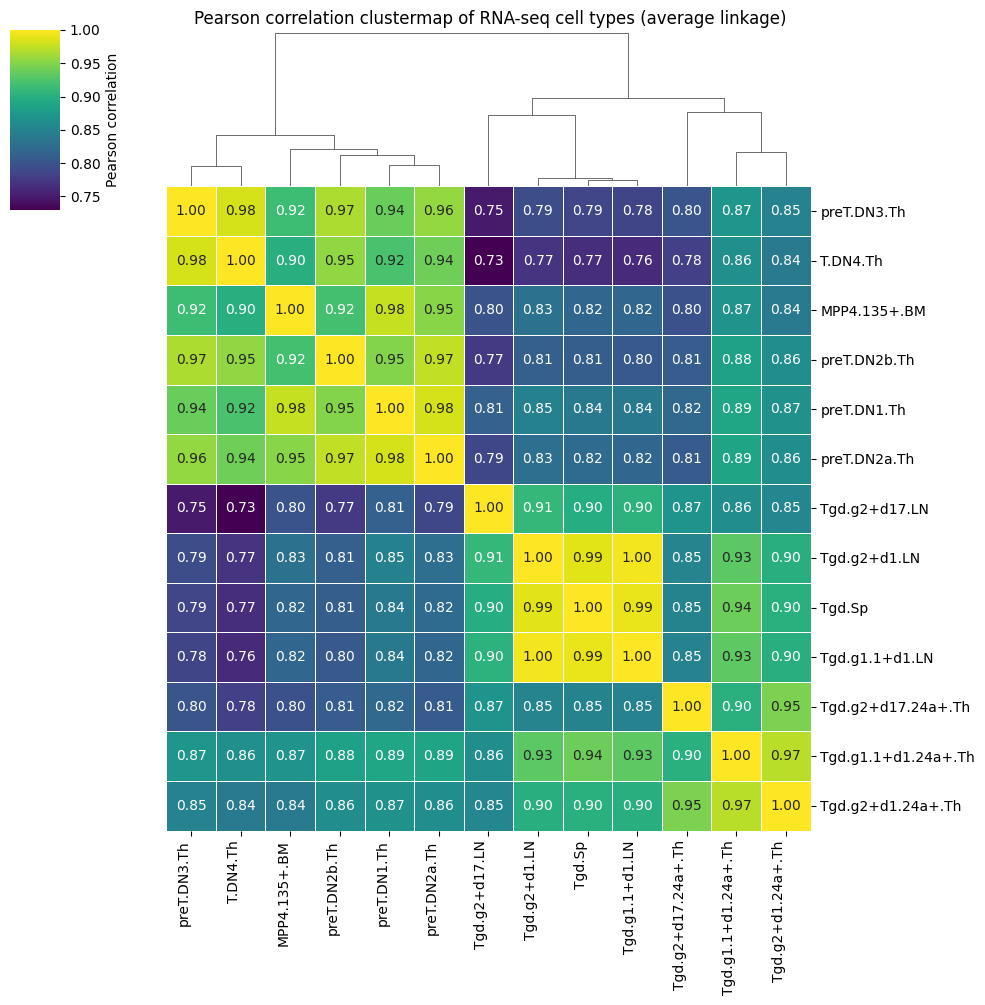

In [23]:
RNA_seq_gd = RNA_seq[Tgd_cells[1:]].copy()

RNA_gd_corr_matrix_pear = RNA_seq_gd[1:].corr(method='pearson')

vmin, vmax = RNA_gd_corr_matrix_pear.min().min(), 1

g = sns.clustermap(
    RNA_gd_corr_matrix_pear,
    cmap='viridis',
    center= (RNA_gd_corr_matrix_pear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of RNA-seq cell types (average linkage)', y=1)
plt.savefig('tilmann_plots/Pearson correlation clustering of RNA-seq cell types (average linkage).png', dpi=300, bbox_inches='tight')
plt.show()

- there is a very clear distinction between Tab progenitor cells and Tgd cells
- it clusters similiarly terminal differentiated cells apart from not fully differentiated
- IL17 producing cells are still quite different from others, but not as far apart as with ATAC data
- some cell types are very similar in their gene expression profile (all progenitor cell before expression of gdTCR and the terminal differentiated Tgd cells except IL17 producers)

## PCA, k-means clustering and Umap

### PCA

In [24]:
RNA_seq_PCA = RNA_seq.iloc[:,8:].T.copy()
RNA_seq_PCA.columns = RNA_seq["Unnamed: 0"]
RNA_seq_PCA_gd = RNA_seq[Tgd_cells[1:]].T.copy()
RNA_seq_PCA_gd.columns = RNA_seq["Unnamed: 0"]

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = RNA_seq_PCA.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_RNA = pd.DataFrame(pcs, index=RNA_seq_PCA.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_RNA_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())

[0.12016114 0.09317275 0.06797908 0.05880787 0.04571388 0.04242933
 0.03727105 0.03100909 0.02917097 0.02707328]
[0.12016114 0.21333388 0.28131296 0.34012083 0.38583472 0.42826405
 0.4655351  0.49654419 0.52571516 0.55278844]


In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = RNA_seq_PCA_gd.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_RNA_gd = pd.DataFrame(pcs, index=RNA_seq_PCA_gd.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_RNA_gd_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())

[0.29017042 0.16484044 0.1164742  0.09402509 0.06150092 0.05384627
 0.04755363 0.04505545 0.0389955  0.03354666]
[0.29017042 0.45501086 0.57148506 0.66551015 0.72701107 0.78085734
 0.82841097 0.87346643 0.91246193 0.94600859]


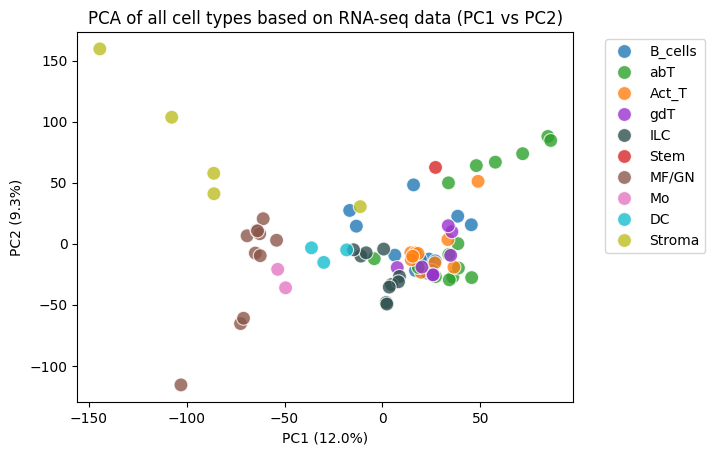

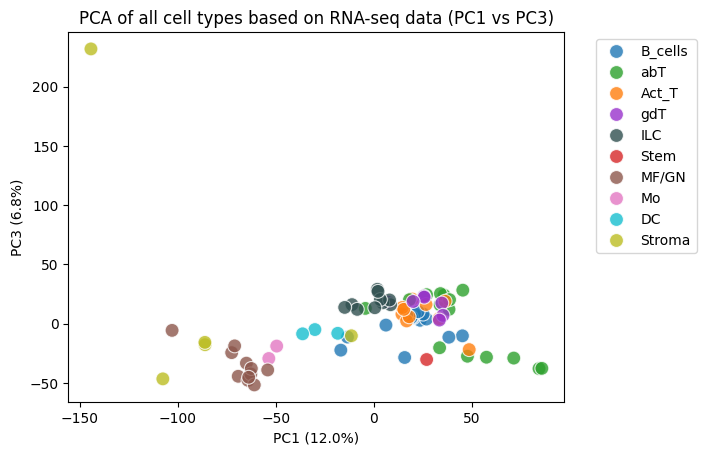

In [27]:
cells_groups = pd.read_csv('data/cells_groups.csv')

cell_group_map = {
    cell: group
    for group in cells_groups.columns
    for cell in cells_groups[group].dropna()
}

pca_RNA["cell_type"] = pca_RNA.index.map(cell_group_map).fillna("Act_T")

group_palette = {
    "gdT": "darkorchid",
    "abT": "tab:green",
    "Act_T": "tab:orange",
    "B_cells": "tab:blue",
    "Stem": "tab:red",
    "ILC": "darkslategrey",
    "MF/GN": "tab:brown",
    "Mo": "tab:pink",
    "DC": "tab:cyan",
    "Stroma": "tab:olive",
    "other": "lightgrey",
}

sns.scatterplot(
    data=pca_RNA,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_RNA_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_RNA_exp_var[1]:.1%})")
plt.title("PCA of all cell types based on RNA-seq data (PC1 vs PC2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig('tilmann_plots/PCA of all cell types based on RNA-seq data (PC1 vs PC2).png', dpi=300, bbox_inches='tight')
plt.show()

sns.scatterplot(
    data=pca_RNA,
    x="PC1",
    y="PC3",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_RNA_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_RNA_exp_var[2]:.1%})")
plt.title("PCA of all cell types based on RNA-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

- distinctions between cell groups are less clear than with ATACseq data

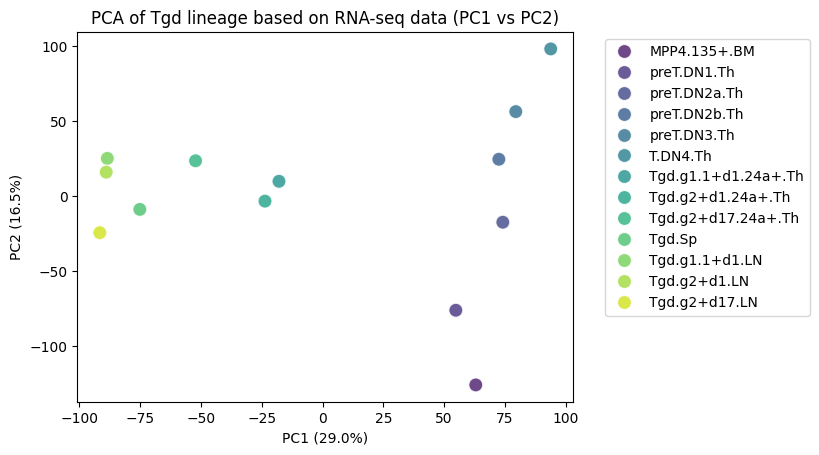

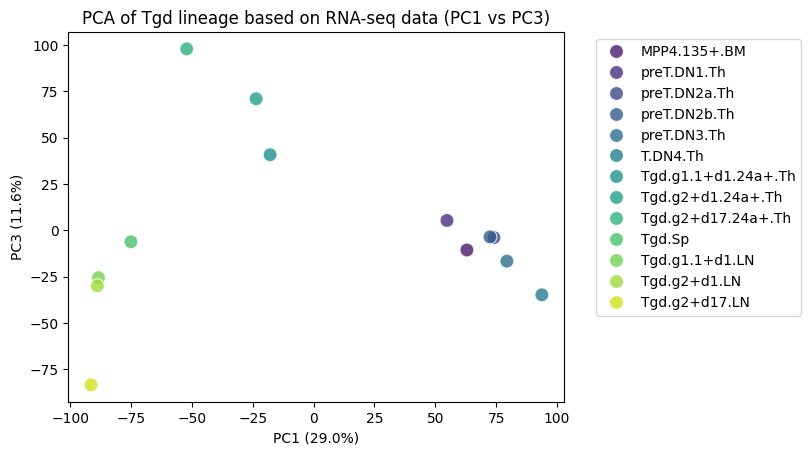

In [28]:
pca_RNA_gd["sample"] = pca_RNA_gd.index

palette = dict(zip(
    pca_RNA_gd["sample"],
    sns.color_palette("viridis", n_colors=len(pca_RNA_gd))
))

sns.scatterplot(data=pca_RNA_gd, x="PC1", y="PC2", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_RNA_gd_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_RNA_gd_exp_var[1]:.1%})")
plt.title("PCA of Tgd lineage based on RNA-seq data (PC1 vs PC2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('tilmann_plots/PCA of Tgd lineage based on RNA-seq data (PC1 vs PC2).png', dpi=300, bbox_inches='tight')
plt.show()

sns.scatterplot(data=pca_RNA_gd, x="PC1", y="PC3", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_RNA_gd_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_RNA_gd_exp_var[2]:.1%})")
plt.title("PCA of Tgd lineage based on RNA-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

- Tgd cells are further apart from the Tab progenitors
    - this overlaps with the hierarchical clustering

### k-means based on PCA

k=2: silhouette score = 0.3393
k=3: silhouette score = 0.3299
k=4: silhouette score = 0.2952
k=5: silhouette score = 0.3045
k=6: silhouette score = 0.3388
k=7: silhouette score = 0.3768
k=8: silhouette score = 0.3904
k=9: silhouette score = 0.4275
k=10: silhouette score = 0.4490
k=11: silhouette score = 0.4105
k=12: silhouette score = 0.4266
k=13: silhouette score = 0.4215
k=14: silhouette score = 0.4355
k=15: silhouette score = 0.4362
k=16: silhouette score = 0.4136
k=17: silhouette score = 0.4333
k=18: silhouette score = 0.4381
k=19: silhouette score = 0.4232


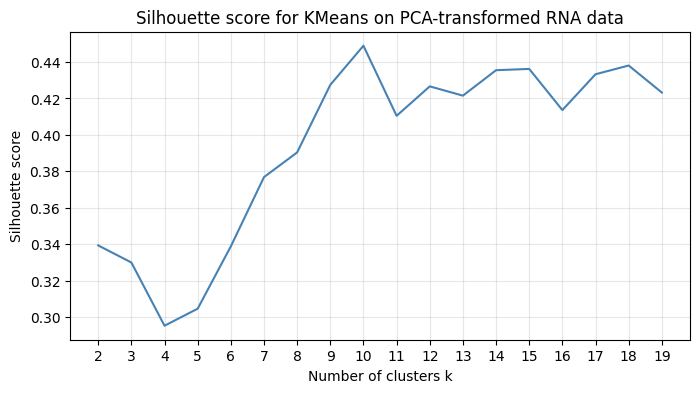

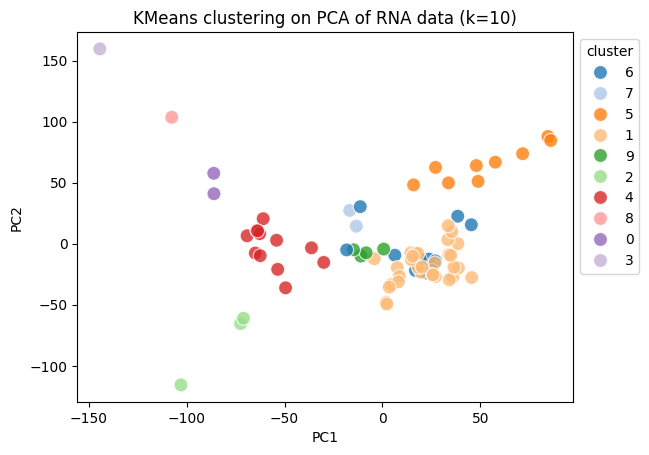

cell_type,Act_T,B_cells,DC,ILC,MF/GN,Mo,Stem,Stroma,abT,gdT
kmeans_cluster,,,,,,,,,,
0,0,0,0,0,0,0,0,2,0,0
1,9,0,0,6,0,0,0,0,9,7
2,0,0,0,0,3,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0
4,0,0,2,0,8,2,0,0,0,0
5,1,1,0,0,0,0,1,0,6,0
6,0,12,1,0,0,0,0,1,0,0
7,0,2,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,1,0,0


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca_features = [f"PC{i+1}" for i in range(min(10, pca_RNA.shape[1]))]
X_pca = pca_RNA[pca_features].values

silhouette_scores = []
k_values = range(2, 20)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on PCA-transformed RNA data")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt = KMeans(n_clusters=best_k, random_state=42, n_init=20)
pca_RNA["kmeans_cluster"] = kmeans_opt.fit_predict(X_pca).astype(str)

sns.scatterplot(
    data=pca_RNA,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab20",
    s=100,
    alpha=0.8
)
plt.title(f"KMeans clustering on PCA of RNA data (k={best_k})")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

pca_RNA.groupby(["kmeans_cluster", "cell_type"]).size().unstack(fill_value=0)

### Umap

/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


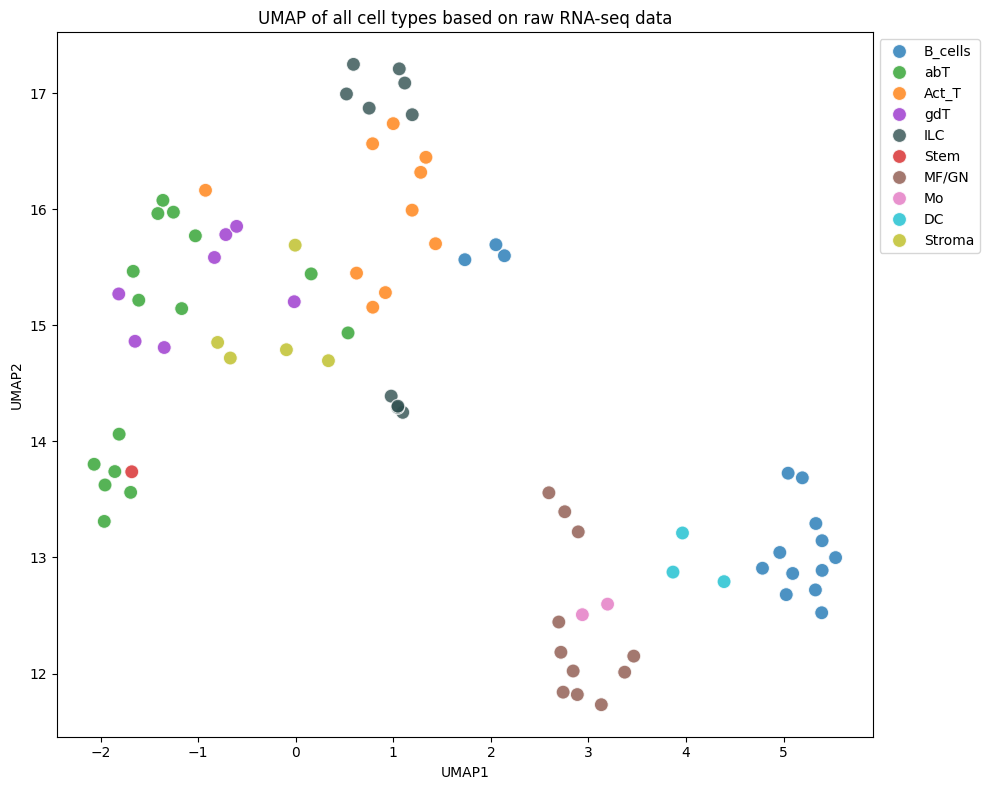

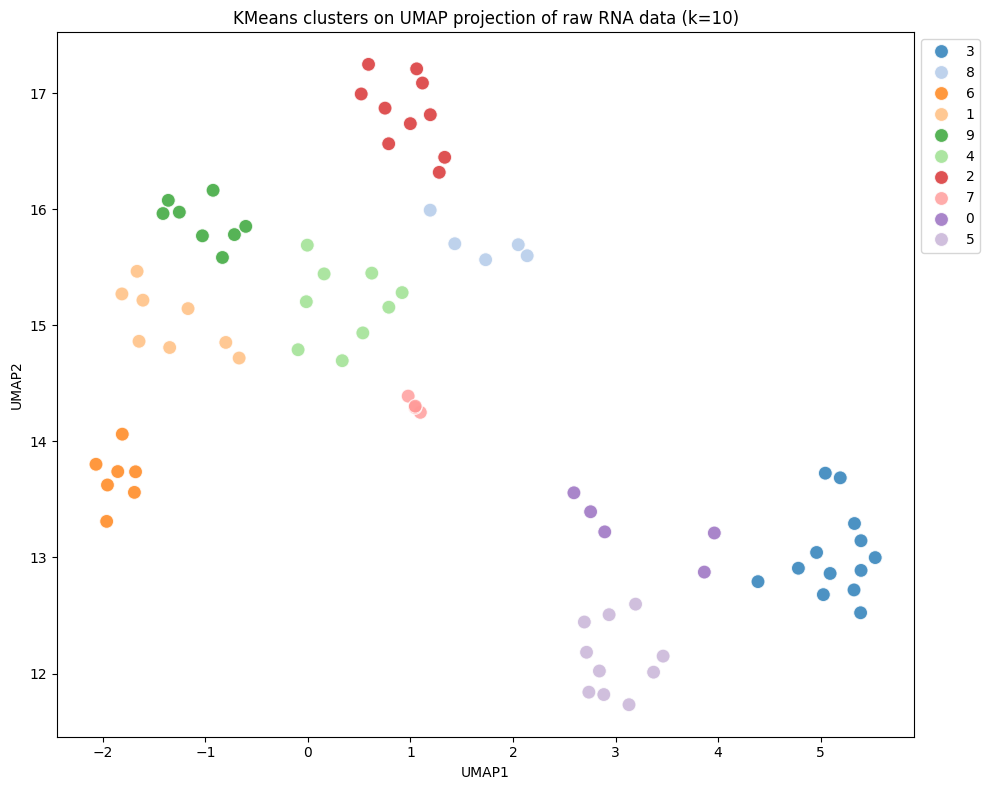

In [30]:
import umap

umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)

X_raw = pca_RNA.select_dtypes(float).values
X_raw_scaled = StandardScaler().fit_transform(X_raw)

X_umap = umap_reducer.fit_transform(X_raw_scaled)
umap_df = pd.DataFrame(
    X_umap,
    index=pca_RNA.index,
    columns=['UMAP1', 'UMAP2']
)
umap_df['cell_type'] = pca_RNA['cell_type']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='cell_type',
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.title('UMAP of all cell types based on raw RNA-seq data')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

kmeans_umap = KMeans(n_clusters=best_k, random_state=42, n_init=20)
umap_df['umap_cluster'] = kmeans_umap.fit_predict(umap_df[['UMAP1', 'UMAP2']]).astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='umap_cluster',
    palette='tab20',
    s=100,
    alpha=0.8
)
plt.title(f'KMeans clusters on UMAP projection of raw RNA data (k={best_k})')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

- the clustering seperation of different cell groups with PCA and Umap based on RNAseq data is worse than with ATACseq data

# Looking at gene expression profiles

## Can genes be grouped into clusters based on their expression profiles across cell types?

### loading the RNAseq data with gene names as index

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq = pd.read_csv('data/mmc2.csv')

RNA_seq_gd = RNA_seq[Tgd_cells[1:]].copy()

RNA_seq_val = RNA_seq.drop(columns="Unnamed: 0").copy()
RNA_seq_val.index = RNA_seq["Unnamed: 0"]
RNA_seq_val

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0610005C13Rik,1.096732,1.096732,1.021750,1.021812,1.205236,1.326780,1.392996,1.821243,1.025543,3.383058,...,1.025785,1.025785,1.251082,1.147249,1.024462,1.019656,1.017884,1.019107,1.017884,1.024720
0610007P14Rik,206.053987,246.105317,192.424636,204.298358,189.759175,210.195155,180.219440,137.802543,139.436719,138.334965,...,121.603448,105.140895,101.841463,175.620707,280.406964,200.228029,208.171821,88.578590,129.021874,140.655763
0610009B22Rik,78.272059,78.837030,68.844751,76.418169,106.085619,77.502817,68.213092,57.224426,56.787489,40.460507,...,88.691426,73.423656,68.881268,60.811907,56.578015,100.397766,37.373080,73.888468,77.191831,84.245816
0610009L18Rik,8.577159,16.791386,15.511549,16.947354,10.583704,8.664784,2.878172,8.952120,11.873984,16.721968,...,6.132818,8.965889,4.080445,11.987408,5.627219,4.227673,2.199352,1.460090,2.482516,1.023995
0610009O20Rik,168.645852,157.926022,155.941641,186.261464,162.584556,152.088002,163.072291,133.116083,88.052982,87.408479,...,102.592399,147.139323,130.924354,107.542142,88.338330,100.779150,86.442408,193.307175,187.212720,45.464889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zyx,1077.279973,1000.129645,1441.710317,1420.833446,892.901412,591.906505,77.225695,76.893407,204.747794,84.490719,...,882.527477,895.552144,644.668492,687.226314,1022.118904,343.590422,626.708360,319.108365,340.709716,47.468741
Zzef1,182.615549,156.086051,171.910668,120.178140,169.880499,191.894767,169.235892,339.923087,320.015523,298.222997,...,265.983706,244.820391,293.192181,339.751833,302.980242,141.832817,271.207059,258.470768,178.385283,182.419304
Zzz3,271.253172,345.990082,299.982528,298.099129,234.594136,210.857607,232.421450,184.330794,181.956962,202.123436,...,148.759166,161.776889,248.030321,220.743890,217.310928,201.993028,209.141118,287.106311,216.491923,227.559035


### K-means based on expression across cell types

k=2: silhouette score = 0.9388
k=3: silhouette score = 0.8579
k=4: silhouette score = 0.7953
k=5: silhouette score = 0.7126
k=6: silhouette score = 0.6495
k=7: silhouette score = 0.6461
k=8: silhouette score = 0.6491
k=9: silhouette score = 0.5730
k=10: silhouette score = 0.5932


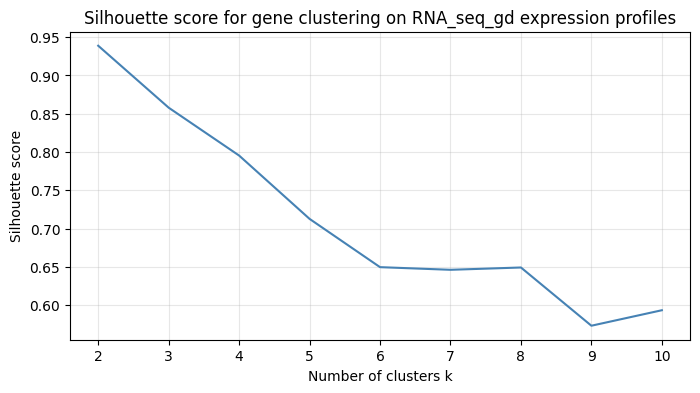

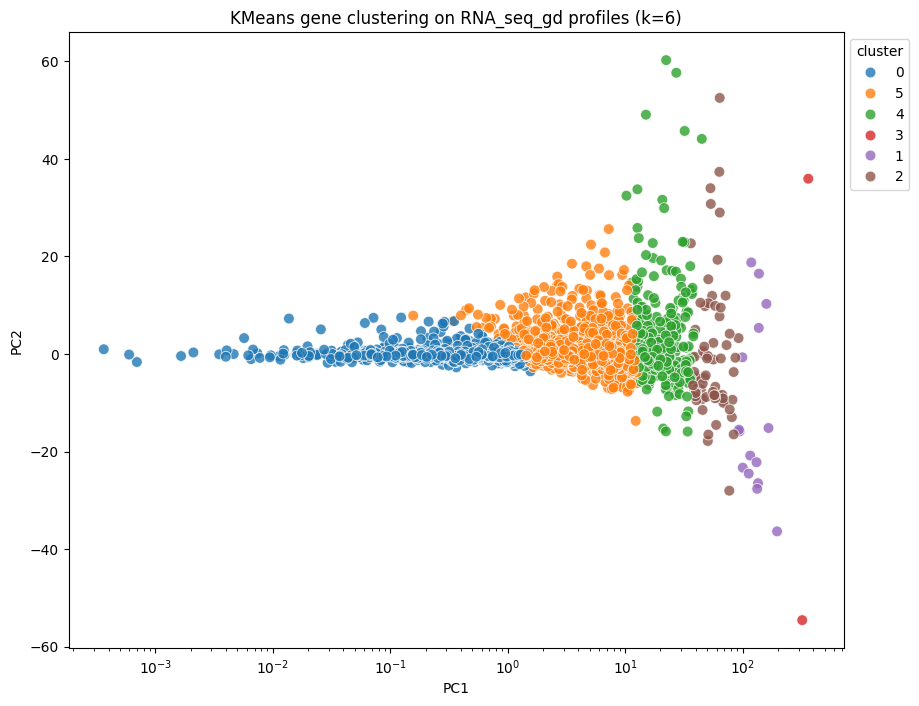

kmeans_cluster
0    14475
5     2595
4      379
2       69
1       15
3        2
dtype: int64


In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

gene_expr = RNA_seq_val.copy().astype(float)
X_scaled = StandardScaler().fit_transform(gene_expr)

n_components = min(10, X_scaled.shape[1], X_scaled.shape[0] - 1)
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for gene clustering on RNA_seq_gd expression profiles")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt = KMeans(n_clusters=6, random_state=42, n_init=20)
labels = kmeans_opt.fit_predict(X_pca)

gene_clusters = pd.DataFrame(
    {
        "gene": gene_expr.index,
        "kmeans_cluster": labels.astype(str),
    }
)

pca_df = pd.DataFrame(X_pca[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df["kmeans_cluster"] = gene_clusters["kmeans_cluster"].values

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=60,
    alpha=0.8,
)
ax.set_xscale("log")
ax.set_yscale("linear")
plt.title(f"KMeans gene clustering on RNA_seq_gd profiles (k={6})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

print(gene_clusters.groupby("kmeans_cluster").size().sort_values(ascending=False))


- no destinct groups can be seen
- other clustering methods could be better

#### trying out clustering of log transformed expression values

In [4]:
def log_transform(df):
    df_numeric_cols = df.select_dtypes(include=[np.number]).columns
    log_df = df.copy()
    log_df[df_numeric_cols] = np.log1p(log_df[df_numeric_cols])
    return log_df

k=2: silhouette score = 0.6077
k=3: silhouette score = 0.4885
k=4: silhouette score = 0.4222
k=5: silhouette score = 0.3791
k=6: silhouette score = 0.3348
k=7: silhouette score = 0.3426
k=8: silhouette score = 0.2992
k=9: silhouette score = 0.2892
k=10: silhouette score = 0.2801


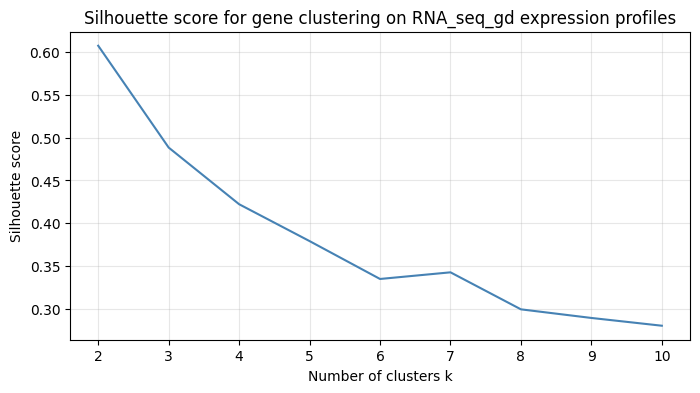

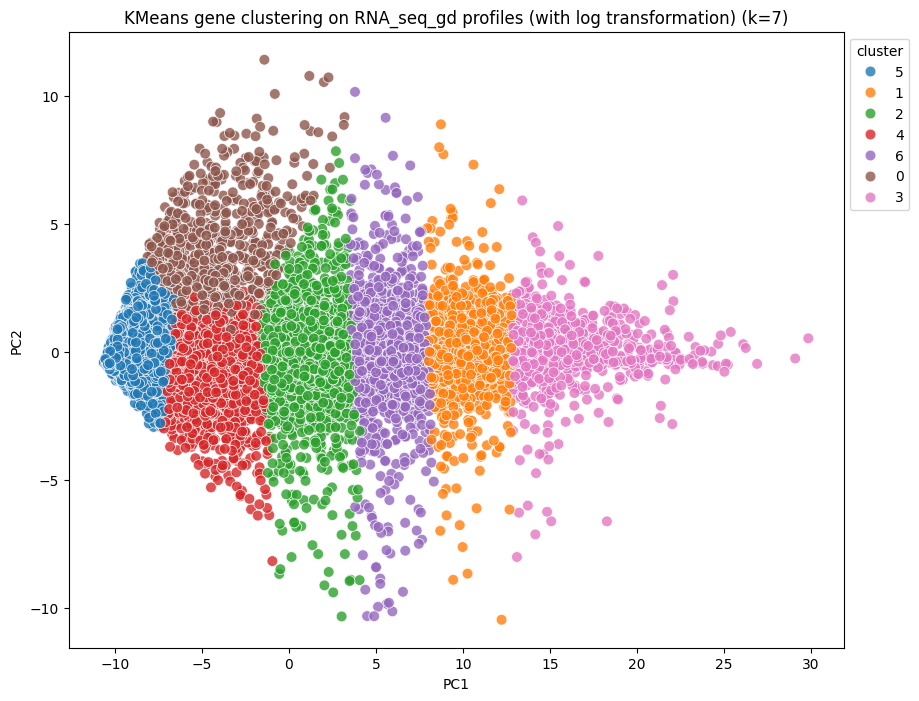

kmeans_cluster
5    5983
6    2966
1    2869
2    2206
4    1677
3    1099
0     735
dtype: int64


In [5]:
gene_expr_log = log_transform(RNA_seq_val).copy().astype(float)
X_scaled_log = StandardScaler().fit_transform(gene_expr_log)

n_components = min(10, X_scaled_log.shape[1], X_scaled_log.shape[0] - 1)
pca_log = PCA(n_components=n_components, random_state=42)
X_pca_log = pca_log.fit_transform(X_scaled_log)

silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca_log)
    score = silhouette_score(X_pca_log, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for gene clustering on RNA_seq_gd expression profiles")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt_log = KMeans(n_clusters=7, random_state=42, n_init=20)
labels = kmeans_opt_log.fit_predict(X_pca_log)

gene_clusters_log = pd.DataFrame(
    {
        "gene": gene_expr.index,
        "kmeans_cluster": labels.astype(str),
    }
)

pca_df_log = pd.DataFrame(X_pca_log[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df_log["kmeans_cluster"] = gene_clusters_log["kmeans_cluster"].values

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    data=pca_df_log,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=60,
    alpha=0.8,
)
ax.set_xscale("linear")
ax.set_yscale("linear")
plt.title(f"KMeans gene clustering on RNA_seq_gd profiles (with log transformation) (k={7})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

print(gene_clusters_log.groupby("kmeans_cluster").size().sort_values(ascending=False))


#### coloring the genes in the PCA plot by their biological function (look at the scatter plot from before)

In [6]:
import gseapy as gp

go_genesets = gp.get_library(name='GO_Biological_Process_2023', organism='Mouse')

gene2terms = {}
for term, genes in go_genesets.items():
    for gene in genes:
        gene2terms.setdefault(gene, set()).add(term)

category_keywords = {
    "housekeeping":  ["ribosom", "translation", "RNA processing",
                      "proteasome", "DNA repair", "cell cycle"],
    "immune":        ["immune", "T cell", "lymphocyte", "cytokine",
                      "interferon", "NF-kB", "antigen"],
    "metabolism":    ["metabolic", "biosynthesis", "oxidation",
                      "glycolysis", "lipid", "mitochondri"],
    "transcription": ["transcription", "chromatin", "histone", "epigenetic"],
    "signaling":     ["signaling", "kinase", "receptor", "MAPK", "PI3K"],
}

In [7]:
def assign_category(gene):
    terms = gene2terms.get(gene.upper(), set())   
    for category, keywords in category_keywords.items():
        for t in terms:                   
            for kw in keywords:           
                if kw.lower() in t.lower():
                    return category       
    return "other"     

In [8]:
color_map = {
    "housekeeping":  "#2196F370",  
    "immune":        "#F4433670",  
    "metabolism":    "#4CAF5070",  
    "transcription": "#FF980070",  
    "signaling":     "#9C27B070",  
    "other":         "#CCCCCC30",  
}

color_map_housekeeping = {  
    "housekeeping":  "#2196F3",  
    "immune":        "#F4433600",  
    "metabolism":    "#4CAF4F00",  
    "transcription": "#FF990000",  
    "signaling":     "#9B27B000",
    "other":         "#CCCCCC30",  
}

color_map_immune = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#F44336",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC30",  
}

color_map_metabolism = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#4CAF50",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC30",  
}

color_map_transcription = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#FF9800",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC30",  
}

color_map_signaling = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#9C27B0",  
    "other":         "#CCCCCC30",  
}

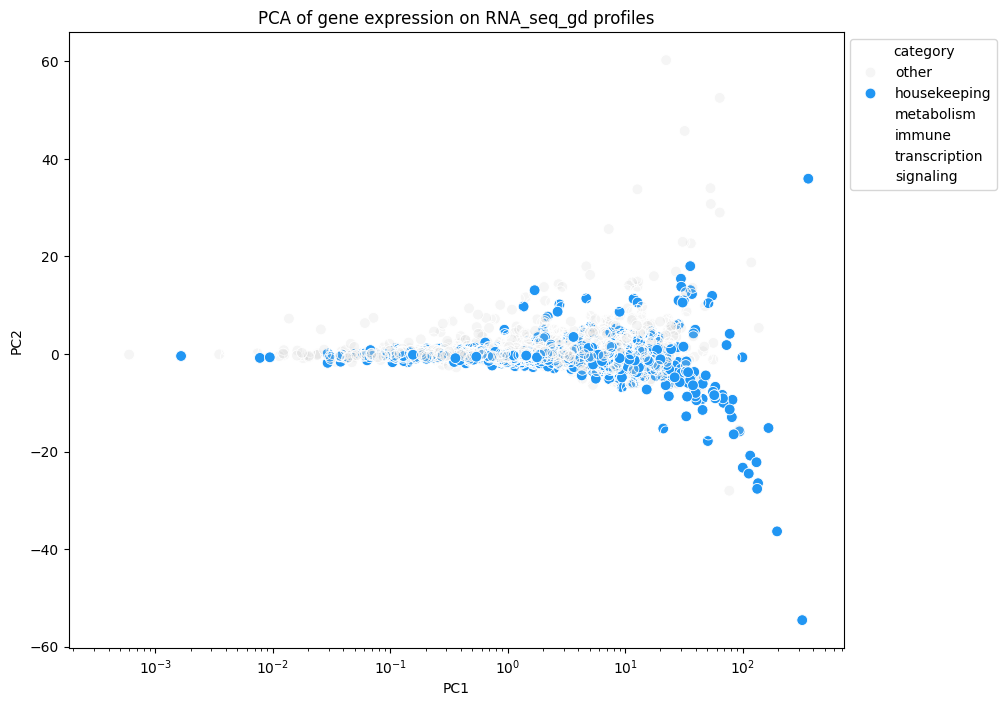

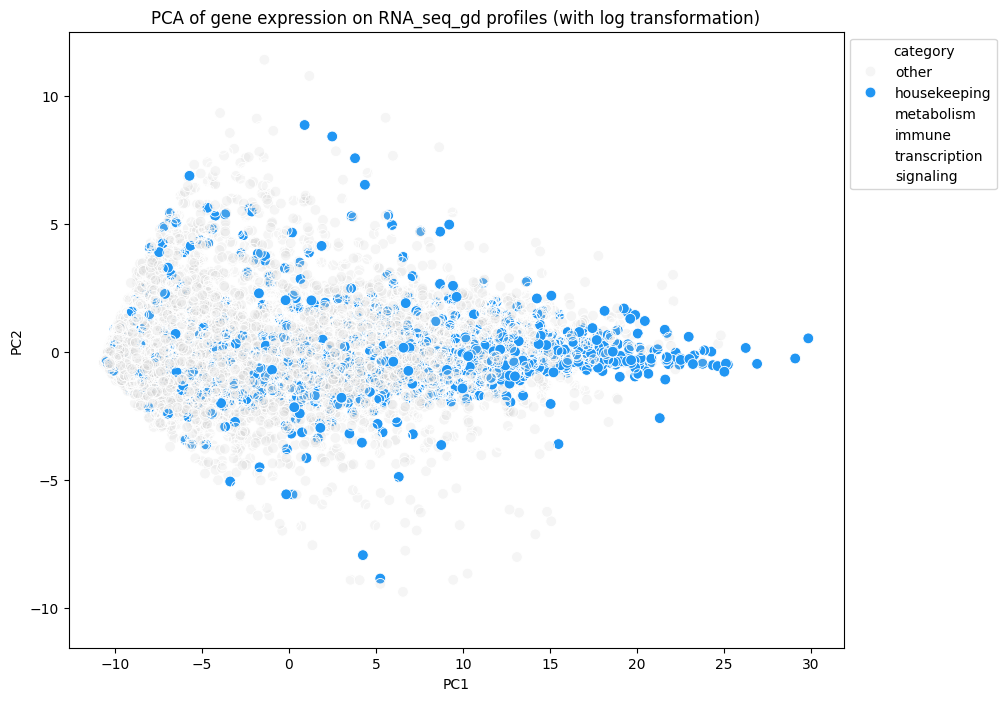

In [9]:
pca_df = pd.DataFrame(X_pca[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df["gene_category"] = pca_df.index.map(assign_category)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="gene_category",
    palette=color_map_housekeeping,
    s=60,
)
plt.xscale("log")
plt.yscale("linear")
plt.title("PCA of gene expression on RNA_seq_gd profiles")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="category", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()




pca_df_log = pd.DataFrame(X_pca_log[:, :2], index=gene_expr.index, columns=["PC1", "PC2"])
pca_df_log["gene_category"] = pca_df_log.index.map(assign_category)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df_log,
    x="PC1",
    y="PC2",
    hue="gene_category",
    palette=color_map_housekeeping,
    s=60,
)
plt.xscale("linear")
plt.yscale("linear")
plt.title("PCA of gene expression on RNA_seq_gd profiles (with log transformation)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="category", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()


### look at the most variable genes and where they are expressed (not used in further analysis)

#### filtering out the top 1000 most variable genes

In [ ]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq_val = RNA_seq.drop(columns="Unnamed: 0").copy()
RNA_seq_val.index = RNA_seq["Unnamed: 0"]
RNA_seq_val

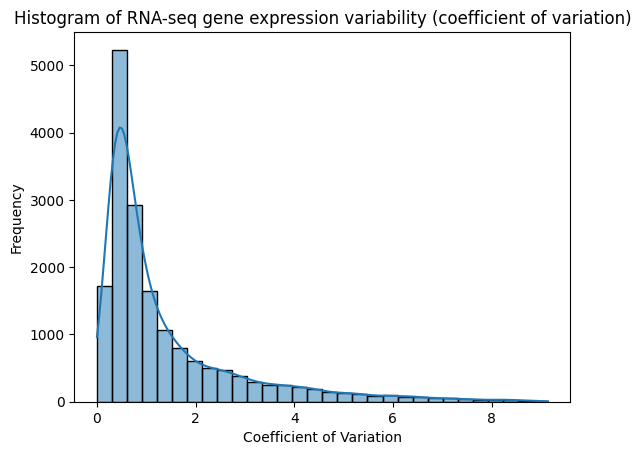

In [15]:
RNA_var_coef = RNA_seq_val.std(axis=1) / RNA_seq_val.mean(axis=1)
sns.histplot(RNA_var_coef, bins=30, kde=True)
plt.title("Histogram of RNA-seq gene expression variability (coefficient of variation)")
plt.xlabel("Coefficient of Variation")
plt.ylabel("Frequency")
plt.show()

In [14]:
top1000_threshold = RNA_var_coef.nlargest(1000).index
rna_var_top1000 = RNA_seq_val.loc[top1000_threshold].copy()

### using Gini index to identify cell type specific genes

computing the Gini score for each gene (function was created using Claude Sonnet 4.6)
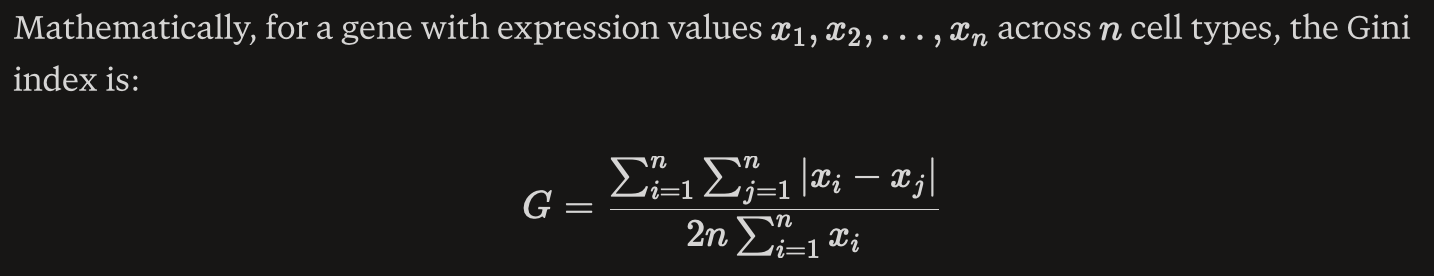

In [ ]:
# --- Gini index function ---
def gini(x):
    """
    Compute the Gini coefficient for a 1D array of expression values.
    Returns a value between 0 (uniform) and 1 (fully specific).
    """
    x = np.array(x, dtype=float)
    x = x[x >= 0]           # remove negative values if any
    if x.sum() == 0:
        return 0.0           # no expression → not informative
    x = np.sort(x)           # sort ascending
    n = len(x)
    cumulative = np.cumsum(x)
    # Gini formula based on the area under the Lorenz curve
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * x.sum()) / (n * x.sum())

RNA_seq_gini = RNA_seq_val.copy()
RNA_seq_gini["gini_score"] = RNA_seq_gini.apply(gini, axis=1)

visualizing the Gini Score using a Umap of all genes

/Users/tilmannstieglitz/Library/Mobile Documents/com~apple~CloudDocs/4.Semester/Bioinformatik/topic04_team03/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


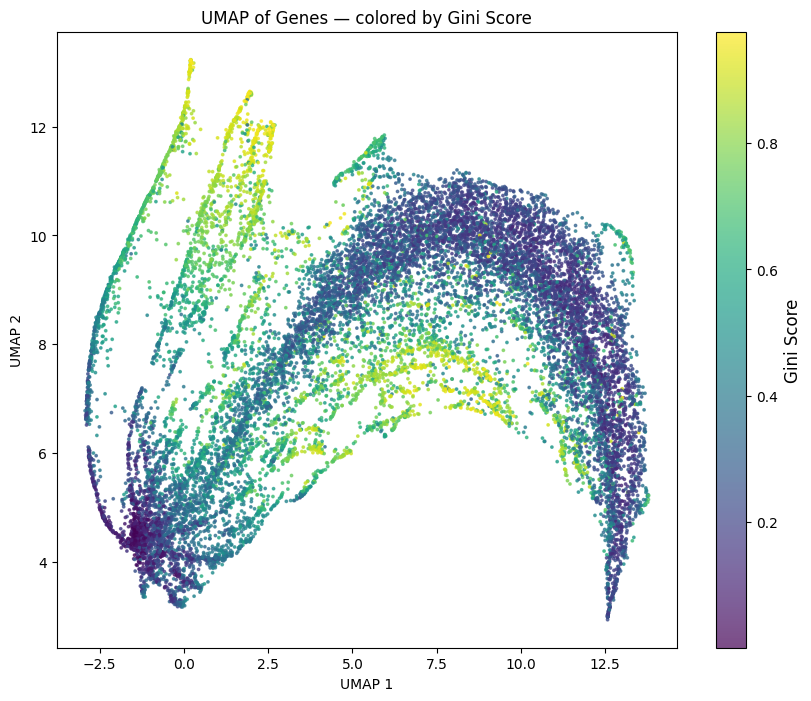

In [47]:
import umap
import matplotlib.cm as cm
import matplotlib.colors as mcolors


reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=30,    # increase if you have many genes (e.g., 30-50)
    min_dist=0.1       # tighter clusters → good for identifying gene groups
)
embedding = reducer.fit_transform(RNA_seq_val.values)

gini_scores = RNA_seq_gini["gini_score"].values
norm = mcolors.Normalize(vmin=gini_scores.min(), vmax=gini_scores.max())
cmap = cm.viridis 

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    embedding[:, 0], embedding[:, 1],
    c=gini_scores,          
    cmap=cmap,
    norm=norm,
    s=3,                    
    alpha=0.7,
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Gini Score", fontsize=12)
cbar.ax.tick_params(labelsize=10)
ax.set_title("UMAP of Genes — colored by Gini Score")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.savefig('tilmann_plots/Umap of Genes: colored by Gini Score', dpi=300)
plt.show()

## Can you identify a lineage-specific gene set for your assigned cell type?

### identify specicfic genes using the Gini Score

In [68]:
Tgd_cells = ["MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

In [ ]:
high_gini_genes = RNA_seq_gini[RNA_seq_gini["gini_score"] >= 0.80].copy()

top_gini_genes = RNA_seq_gini.nlargest(100, "gini_score").copy()

expr_only = high_gini_genes.drop(columns=["gini_score"])

high_gini_genes["dominant_cell_type"] = expr_only.idxmax(axis=1)

high_gini_genes["specificity_ratio"] = expr_only.max(axis=1) / expr_only.mean(axis=1)

marker_table = (
    high_gini_genes[["gini_score", "dominant_cell_type", "specificity_ratio"]]
    .sort_values(["dominant_cell_type", "gini_score"], ascending=[True, False])
)

,gini_score,dominant_cell_type,specificity_ratio
Unnamed: 0,,,
Flt3,0.903410,MPP4.135+.BM,14.439182
9030619P08Rik,0.884571,MPP4.135+.BM,15.380138
Gm5111,0.857728,MPP4.135+.BM,13.519844
Vldlr,0.853127,MPP4.135+.BM,20.095940
Slc35d3,0.833252,MPP4.135+.BM,18.429544
Hnf4a,0.832745,MPP4.135+.BM,17.068068
Sgsm1,0.827518,MPP4.135+.BM,13.017644
Pdcd1,0.851216,Tgd.g1.1+d1.24a+.Th,17.715146
Mpp4,0.815215,Tgd.g1.1+d1.24a+.Th,21.282237


In [80]:
gene_threshold = expr_only.mean(axis=1) + (1 * expr_only.std(axis=1)) 


marker_dict = {}

for cell_type in expr_only.columns:
    genes_above_threshold = expr_only.index[expr_only[cell_type] > gene_threshold].tolist()
    marker_dict[cell_type] = genes_above_threshold


max_len = max(len(g) for g in marker_dict.values())

specific_genes = pd.DataFrame({
    cell_type: genes + [""] * (max_len - len(genes))
    for cell_type, genes in marker_dict.items()
})

specific_genes

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,Adamtsl5,Adgrg1,9030619P08Rik,9030619P08Rik,9030619P08Rik,9030619P08Rik,Alpl,4930426D05Rik,Ackr2,4930426D05Rik,...,1810011O10Rik,1810011O10Rik,1600010M07Rik,1600010M07Rik,AI607873,A4galt,Acta2,1810011O10Rik,9430020K01Rik,1810011O10Rik
1,Adgrg1,Adgrl4,Adgrg1,Adgrg1,Adgrg3,Adgrg3,Bcat1,Bank1,Bank1,Bank1,...,4930455G09Rik,4930455G09Rik,AF251705,A530099J19Rik,Adam11,Abca8a,Adam11,6430548M08Rik,A4galt,2210407C18Rik
2,Adgrl4,Afap1l1,Adgrl4,Adgrg3,Bex6,Bex6,Bfsp2,Bcar3,Bhlhe41,Bcar3,...,6430548M08Rik,6430548M08Rik,AI607873,Acvrl1,Alox5ap,Abcc9,Adm,8430408G22Rik,AW551984,5330417C22Rik
3,Afap1l1,Ak1,Afap1l1,Adgrl4,Cd34,Bfsp2,Cecr2,Bfsp2,Blk,Bfsp2,...,Abca9,AI607873,Adam11,Adam11,Arhgef10l,Abhd3,Adrbk2,9430020K01Rik,Abca13,A4galt
4,Ak1,Aldh1a1,Angpt1,Afap1l1,Cox6a2,Camkv,Cplx2,Blk,Cacna1e,Blk,...,Abcd2,Abca9,Adam23,Adam23,Atp1a3,Abi3bp,Ankrd33b,A4galt,Ablim3,AA467197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,,,,,,,,,,,...,,,,,,Wdr86,,,,
475,,,,,,,,,,,...,,,,,,Wwtr1,,,,
476,,,,,,,,,,,...,,,,,,Yap1,,,,
477,,,,,,,,,,,...,,,,,,Zcchc14,,,,


what genes are specifically expressed in our cell types?

In [83]:
Tgd_specific_genes = specific_genes[Tgd_cells]
Tgd_specific_genes

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,9030619P08Rik,9030619P08Rik,1500009L16Rik,1500009L16Rik,1500009L16Rik,1500009L16Rik,Ccr9,5830411N06Rik,5830411N06Rik,Art2b,Cxcr3,Crtam,5830411N06Rik
1,Adgrg1,Adgrg1,9030619P08Rik,Angptl2,Angptl2,Aqp11,Cd163l1,Ankrd6,Angptl2,Crtam,Dapl1,Cxcr3,Abi3bp
2,Adgrg3,Adgrg3,Adgrg1,Aqp11,Aqp11,Arpp21,Cpa3,Blk,Ankrd6,Gpr15,Gpr15,Dapl1,Adam12
3,Adgrl4,Afap1l1,Adgrg3,Arpp21,Arhgef10l,Bcat1,Dbn1,Ccr4,Blk,Klri1,Itgae,Dmrta1,Adam8
4,Afap1l1,Angpt1,Angpt1,Bpifc,Arpp21,Bmp7,Izumo1r,Ccr8,Bmp7,Pdcd1,Nsg2,Gpr15,Ankrd35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
474,,,,,,,,,,,,,
475,,,,,,,,,,,,,
476,,,,,,,,,,,,,
477,,,,,,,,,,,,,


number of specific genes tends to decrease as the cells get more differentiated

## Are there subclusters of particular biological interest?